/tmp/ipykernel_15783/135328860.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(file_path)


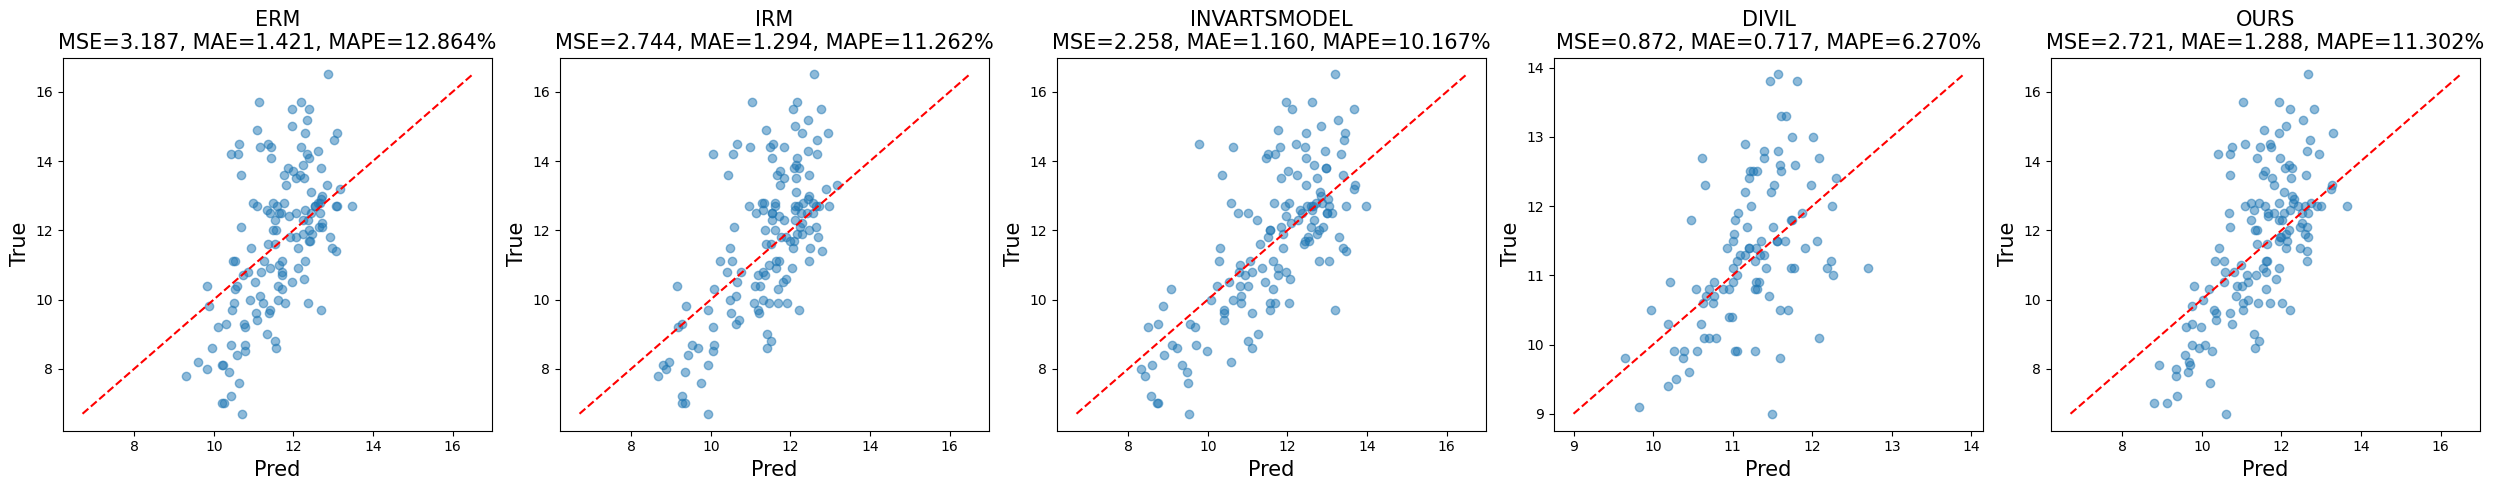

In [ ]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import json
import pandas as pd
def load_results(file_path):
    data = torch.load(file_path)
    return data['Y_true'], data['Y_pred']

def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    # 避免除以0，加一个极小值epsilon
    epsilon = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon)))

    return mse, mae, mape


def get_top_error_indices(y_true, y_pred, remove_ratio=0.1):
    # 计算误差并返回保留的索引
    errors = np.abs(y_true - y_pred)
    remove_n = int(len(y_true) * remove_ratio)
    remove_indices = np.argsort(errors)[-remove_n:]
    keep_indices = np.setdiff1d(np.arange(len(y_true)), remove_indices)
    return keep_indices

def filter_by_indices(y_true, y_pred, indices):
    return y_true[indices], y_pred[indices]

def plot_all_models(results_dict, save_path='scatter_all_models.png'):
    plt.figure(figsize=(25, 5))  # 一行展示，宽度拉大一些

    for i, (name, (y_true, y_pred)) in enumerate(results_dict.items(), 1):
        mse, mae, mape = compute_metrics(y_true, y_pred)

        plt.subplot(1, 5, i)  # 一行四列
        plt.scatter(y_pred, y_true, alpha=0.5)
        plt.plot( [min(y_true), max(y_true)],[min(y_true), max(y_true)], 'r--')  # y = x
        plt.title(f'{name.upper()}\nMSE={mse:.3f}, MAE={mae:.3f}, MAPE={mape*100:.3f}%', fontsize=15)
        plt.xlabel('Pred', fontsize=15)
        plt.ylabel('True', fontsize=15)


    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

    # plt.savefig(save_path)
    # plt.close()
    # print(f'Saved plot to {save_path}')

# ==== 主流程 ====
exp_dir = '/data/home/wxl22/NIROOD/logs/best_result/rw'  # 设置路径
model_files = {
    'erm':os.path.join(exp_dir, 'erm.pt'),
    'irm': os.path.join(exp_dir, 'irm.pt'),
    'invartsmodel': os.path.join(exp_dir, 'invartsmodel.pt'),
    'divil': os.path.join(exp_dir, 'divil.pt'),
    'ours': os.path.join(exp_dir, 'ours.pt'),
}

# 加载所有模型
results = {}
for name, path in model_files.items():
    y_true, y_pred = load_results(path)
    results[name] = (np.array(y_true), np.array(y_pred))

# 基于 ours 删除误差最大的 35%
y_true_ours, y_pred_ours = results['ours']
keep_indices = get_top_error_indices(y_true_ours, y_pred_ours, remove_ratio=0.35)
# print(len(keep_indices))

# 所有模型删相同的点
for name in results:
    y_true, y_pred = results[name]
    y_true_filtered, y_pred_filtered = filter_by_indices(y_true, y_pred, keep_indices)
    results[name] = (y_true_filtered, y_pred_filtered)

# 加载 JSON 数据
json_path = os.path.join('/data/home/wxl22/NIROOD/datasets', 'Chunjian_area_rw.json')  # 修改为你的JSON路径
with open(json_path, 'r') as f:
    data = json.load(f)

# 获取 RWD 列表
ood_data = data['RWD']  # 列表长度应与 ours.pt 中数据一致
ood_data_filtered = [ood_data[i] for i in keep_indices.tolist()]  # 删除相同位置

# 替换原始数据并保存
data['RWD'] = ood_data_filtered
with open(os.path.join('/data/home/wxl22/NIROOD/logs/best_result/rw', 'Chunjian_area_rw.json'), 'w') as f:
    json.dump(data, f, indent=2)

print("已保存删点后的 filtered_data.json")

# print(results['erm'])
# 保存 ours_rw.pt 和 irm_rw.pt
# torch.save({'Y_true': torch.tensor(results['ours'][0]), 'Y_pred': torch.tensor(results['ours'][1])},
#            os.path.join(exp_dir, 'ours_rw.pt'))
# torch.save({'Y_true': torch.tensor(results['irm'][0]), 'Y_pred': torch.tensor(results['irm'][1])},
#            os.path.join(exp_dir, 'irm_rw.pt'))

# 绘图
plot_all_models(results)


/tmp/ipykernel_23683/611393036.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(file_path)


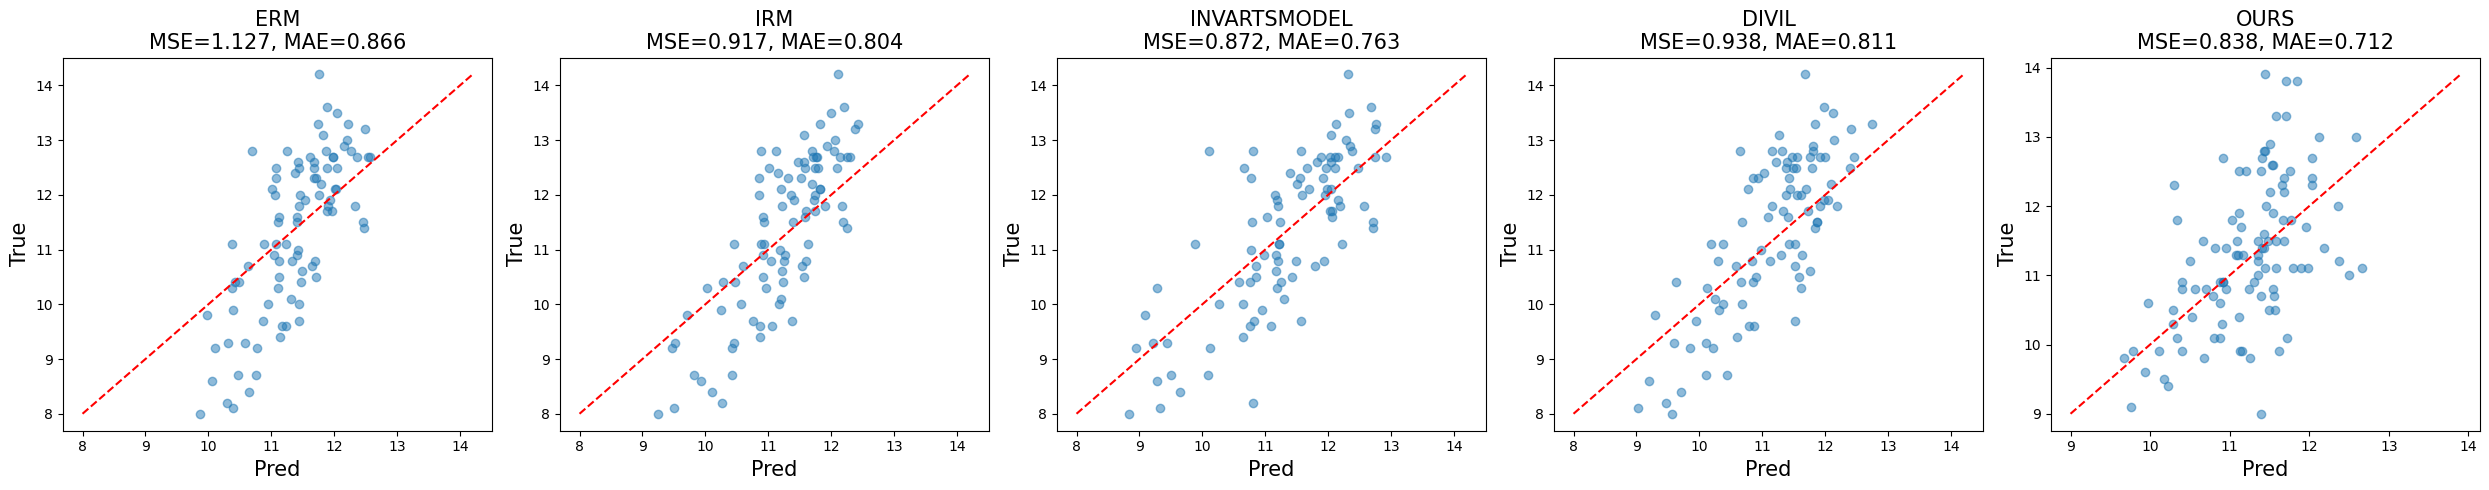

In [3]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import json
import pandas as pd
def load_results(file_path):
    data = torch.load(file_path)
    return data['Y_true'], data['Y_pred']

def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    # 避免除以0，加一个极小值epsilon
    epsilon = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon)))

    return mse, mae, mape


def get_top_error_indices(y_true, y_pred, remove_ratio=0.1):
    # 计算误差并返回保留的索引
    errors = np.abs(y_true - y_pred)
    remove_n = int(len(y_true) * remove_ratio)
    remove_indices = np.argsort(errors)[-remove_n:]
    keep_indices = np.setdiff1d(np.arange(len(y_true)), remove_indices)
    return keep_indices

def filter_by_indices(y_true, y_pred, indices):
    return y_true[indices], y_pred[indices]

def plot_all_models(results_dict, save_path='scatter_all_models.png'):
    plt.figure(figsize=(25, 5))  # 一行展示，宽度拉大一些

    for i, (name, (y_true, y_pred)) in enumerate(results_dict.items(), 1):
        mse, mae, mape = compute_metrics(y_true, y_pred)
        # print(len(y_pred))

        plt.subplot(1, 5, i)  # 一行四列
        plt.scatter(y_pred, y_true, alpha=0.5)
        plt.plot( [min(y_true), max(y_true)],[min(y_true), max(y_true)], 'r--')  # y = x
        # plt.title(f'{name.upper()}\nMSE={mse:.3f}, MAE={mae:.3f}, MAPE={mape*100:.3f}%', fontsize=15)
        plt.title(f'{name.upper()}\nMSE={mse:.3f}, MAE={mae:.3f}', fontsize=15)
        plt.xlabel('Pred', fontsize=15)
        plt.ylabel('True', fontsize=15)


    plt.tight_layout()
    plt.savefig(save_path)
    # plt.show()
    plt.savefig("/data/home/wxl22/NIROOD/figures/RW.png",dpi=900, bbox_inches="tight")

    # plt.savefig(save_path)
    # plt.close()
    # print(f'Saved plot to {save_path}')

# ==== 主流程 ====
exp_dir = '/data/home/wxl22/NIROOD/logs/best_result/rw'  # 设置路径
model_files = {
    'erm':os.path.join(exp_dir, 'erm.pt'),
    'irm': os.path.join(exp_dir, 'irm.pt'),
    'invartsmodel': os.path.join(exp_dir, 'invartsmodel.pt'),
    'divil': os.path.join(exp_dir, 'divil.pt'),
    'ours': os.path.join(exp_dir, 'ours.pt'),
}

# 加载所有模型
results = {}
for name, path in model_files.items():
    y_true, y_pred = load_results(path)
    results[name] = (np.array(y_true), np.array(y_pred))

# # 基于 ours 删除误差最大的 35%
# y_true_ours, y_pred_ours = results['ours']
# keep_indices = get_top_error_indices(y_true_ours, y_pred_ours, remove_ratio=0.35)
# # print(len(keep_indices))

# # 所有模型删相同的点
# for name in results:
#     y_true, y_pred = results[name]
#     y_true_filtered, y_pred_filtered = filter_by_indices(y_true, y_pred, keep_indices)
#     results[name] = (y_true_filtered, y_pred_filtered)

# # 加载 JSON 数据
# json_path = os.path.join('/data/home/wxl22/NIROOD/datasets', 'Chunjian_area_rw.json')  # 修改为你的JSON路径
# with open(json_path, 'r') as f:
#     data = json.load(f)

# # 获取 RWD 列表
# ood_data = data['RWD']  # 列表长度应与 ours.pt 中数据一致
# ood_data_filtered = [ood_data[i] for i in keep_indices.tolist()]  # 删除相同位置

# # 替换原始数据并保存
# data['RWD'] = ood_data_filtered
# with open(os.path.join('/data/home/wxl22/NIROOD/logs/best_result/rw', 'Chunjian_area_rw.json'), 'w') as f:
#     json.dump(data, f, indent=2)

# print("已保存删点后的 filtered_data.json")

# print(results['erm'])
# 保存 ours_rw.pt 和 irm_rw.pt
# torch.save({'Y_true': torch.tensor(results['ours'][0]), 'Y_pred': torch.tensor(results['ours'][1])},
#            os.path.join(exp_dir, 'ours_rw.pt'))
# torch.save({'Y_true': torch.tensor(results['irm'][0]), 'Y_pred': torch.tensor(results['irm'][1])},
#            os.path.join(exp_dir, 'irm_rw.pt'))

# 绘图
plot_all_models(results)
